# Functional Density Forecasting (FDF) Simulation

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt

import joblib
import logging
from datetime import datetime
from pathlib import Path
from tqdm.auto import tqdm

import sys
sys.path.append('../')
import src.forecasting.simulations      as sim
import src.fda.plots                    as fplt
import src.fda.kde.estimators           as kde
import src.forecasting.cross_validation as crossVal
import src.fda.kde.utils            as dens_utils


np.random.seed(1234)

In [2]:
def format_records(measures, metadata):
    records = []
    
    for m in measures:
        record = {
            **metadata,
            "fold": m["fold"] + 1,
            "KLD": m["KLD"],
            "JSD": m["JSD"],
            "L_1": m["L_1"],
            "L_2": m["L_2"],
            "L_INFTY": m["L_INFTY"],
            "fold_fc_date": m["curves_fc_date"],
            "curves": m["curves"]
        }
        records.append(record)
        
    return records

In [3]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
LOG_PATH       : str = f'../logs/simulations/{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/'
DATABASES_PATH : str = f'../data/interim/simulation/{EXECUTION_DATE}/databases/'
ALL_KDES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/all_kdes.jbl'
CV_FILES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/progress/'

Path(FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(DATABASES_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FILES_PATH).mkdir(parents=True, exist_ok=True)

In [4]:
# simulation objects
N_CURVES  = 300
N_REPS    = 50
N_RETURNS = 288 # (60/5)*12
m = 5001
x = np.linspace(-10, 10, m)
u = np.linspace(0, 1, m)

# base densities
pdf_normal = sim.generate_base_density(
                                       grid=x, 
                                       kind='gaussian',
                                       sigma=2, 
                                       mu=0
                                       )
pdf_t      = sim.generate_base_density(
                                       grid=x, 
                                       kind='student_t', 
                                       df=4, 
                                       scale=np.sqrt(2)
                                       )
base_densities = {
    "normal": pdf_normal,
    "t": pdf_t
}

# parameters
param_grid = {
    'base_pdf_name': list(base_densities.keys()),
    'basis': ['sine'],
    'dimensions': [2, 3, 4],
    'noise_type': ['Null', 'bb', 'functional_noise'],
    'error_sigma': [0.25],
}

scenarios = list(ParameterGrid(param_grid))

scenarios = []
for i, params in enumerate(ParameterGrid(param_grid)):
    params['scenario_id'] = i
    scenarios.append(params)

In [151]:
# SIMULATE DATABASES
simulations_database = {}

n_scenarios = len(scenarios)

for scen_count, scenario in enumerate(scenarios, start=1):
    print(scenario)

    scenario_id = scenario["scenario_id"]
    pdf = base_densities[scenario['base_pdf_name']]

    simulations_database[scenario_id] = {
        "params": scenario.copy(),
        "replications": {}   # <-- FIX: now indexed by n_rep
    }

    for n_rep in range(N_REPS):
        print(f"\t{n_rep+1}/{N_REPS}")

        sim_engine = sim.FDFSimulator(u_grid=u, x_grid=x)

        sim_engine.run_simulation( 
            n_curves    = N_CURVES, 
            base_pdf    = pdf,
            basis       = scenario["basis"],   
            dimensions  = scenario["dimensions"],
            noise_type  = scenario["noise_type"],
            error_sigma = scenario["error_sigma"]
        )

        simulations_database[scenario_id]["replications"][n_rep] = {
            "densities": sim_engine.result["densities"],
            "samples":   sim_engine.get_samples_df(n_samples=N_RETURNS)
        }

    print(f"{scen_count}/{n_scenarios}")

{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 0}
	1/50
	2/50
	3/50
	4/50
	5/50
	6/50
	7/50
	8/50
	9/50
	10/50
	11/50
	12/50
	13/50
	14/50
	15/50
	16/50
	17/50
	18/50
	19/50
	20/50
	21/50
	22/50
	23/50
	24/50
	25/50
	26/50
	27/50
	28/50
	29/50
	30/50
	31/50
	32/50
	33/50
	34/50
	35/50
	36/50
	37/50
	38/50
	39/50
	40/50
	41/50
	42/50
	43/50
	44/50
	45/50
	46/50
	47/50
	48/50
	49/50
	50/50
1/18
{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'bb', 'scenario_id': 1}
	1/50
	2/50
	3/50
	4/50
	5/50
	6/50
	7/50
	8/50
	9/50
	10/50
	11/50
	12/50
	13/50
	14/50
	15/50
	16/50
	17/50
	18/50
	19/50
	20/50
	21/50
	22/50
	23/50
	24/50
	25/50
	26/50
	27/50
	28/50
	29/50
	30/50
	31/50
	32/50
	33/50
	34/50
	35/50
	36/50
	37/50
	38/50
	39/50
	40/50
	41/50
	42/50
	43/50
	44/50
	45/50
	46/50
	47/50
	48/50
	49/50
	50/50
2/18
{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'e

In [5]:
# joblib.dump(simulations_database, f"{FILES_PATH}simulation_database.jbl")

# simulations_database = joblib.load(f"../data/interim/simulation/20260413/simulation_database.jbl")
simulations_database = joblib.load('../data/interim/simulation/20260415/simulation_database.jbl')

In [6]:
# KDE params
# t_dfs = range(3,6)
t_dfs = [3]

rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate"],
    "kernel": ["gaussian"], 
    "cv": [5]#[5]
}

adaptive_grid = {
    "method": ["adaptive"], 
    "kernel": ["gaussian"]
}

lcv_t_grid = {
    "method": ["cross_validate"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
    "cv": [5]
}

adaptive_grid_t = {
    "method": ["adaptive"], 
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
}


density_param_grid = {}
for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_rot_robust : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': True}
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
	 gaussian_cross_validate : {'cv': 5, 'kernel': 'gaussian', 'method': 'cross_validate'}
	 t-student_cross_validate_df=3 : {'cv': 5, 'df': 3, 'kernel': 't-student', 'method': 'cross_validate'}
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'adaptive'}
Total KDE models: 6


In [7]:
scenarios_subset_1 = [x for x in scenarios if x["noise_type"]=='Null']
scenarios_subset_2 = [x for x in scenarios if x["noise_type"]=='functional_noise']
scenarios_subset   = scenarios_subset_1 + scenarios_subset_2
# scenarios_subset   = [x for x in scenarios_subset if x["scenario_id"] >= 5]
subset_ids = [x["scenario_id"] for x in scenarios_subset]
filtered_db = {
    k: v for k, v in simulations_database.items()
    if k in subset_ids
}

In [8]:
scenarios_test = [0,9]
scenarios_subset_cv = [x for x in scenarios if x["scenario_id"] in scenarios_test]
subset_id = [x["scenario_id"] for x in scenarios_subset_cv]
filtered_db = {
    k: v for k, v in simulations_database.items()
    if k in subset_id
}

In [156]:
kde_databases = {}
for scenario, database in filtered_db.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = filtered_db[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities
                }

            # kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{CV_FILES_PATH}scenario_{scenario}_rep_{n_rep}_kde_{kde_bw_name}.jbl")

            del df_h
            del df_grids
            del df_densities
            del kde_params


Processing configuration for {'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 0}
	0
	 simulation n. = 0: gaussian_rot_robust
	 simulation n. = 0: gaussian_rot
	 simulation n. = 0: gaussian_cross_validate
	 simulation n. = 0: t-student_cross_validate_df=3
	 simulation n. = 0: gaussian_adaptive
	 simulation n. = 0: t-student_adaptive_df=3
	1
	 simulation n. = 1: gaussian_rot_robust
	 simulation n. = 1: gaussian_rot
	 simulation n. = 1: gaussian_cross_validate
	 simulation n. = 1: t-student_cross_validate_df=3
	 simulation n. = 1: gaussian_adaptive
	 simulation n. = 1: t-student_adaptive_df=3
	2
	 simulation n. = 2: gaussian_rot_robust
	 simulation n. = 2: gaussian_rot
	 simulation n. = 2: gaussian_cross_validate
	 simulation n. = 2: t-student_cross_validate_df=3
	 simulation n. = 2: gaussian_adaptive
	 simulation n. = 2: t-student_adaptive_df=3
	3
	 simulation n. = 3: gaussian_rot_robust
	 simulation n. = 3: gaussian_

/Users/vizzotto/Documents/GitHub/densities4risk/notebooks/../src/fda/kde/estimators.py:396: UserWarning: Optimal bandwidth (0.0638) is at the boundary of the grid for kernel 't-student'.
  warnings.warn(


	 simulation n. = 7: gaussian_adaptive
	 simulation n. = 7: t-student_adaptive_df=3
	8
	 simulation n. = 8: gaussian_rot_robust
	 simulation n. = 8: gaussian_rot
	 simulation n. = 8: gaussian_cross_validate
	 simulation n. = 8: t-student_cross_validate_df=3
	 simulation n. = 8: gaussian_adaptive
	 simulation n. = 8: t-student_adaptive_df=3
	9
	 simulation n. = 9: gaussian_rot_robust
	 simulation n. = 9: gaussian_rot
	 simulation n. = 9: gaussian_cross_validate
	 simulation n. = 9: t-student_cross_validate_df=3
	 simulation n. = 9: gaussian_adaptive
	 simulation n. = 9: t-student_adaptive_df=3
	10
	 simulation n. = 10: gaussian_rot_robust
	 simulation n. = 10: gaussian_rot
	 simulation n. = 10: gaussian_cross_validate
	 simulation n. = 10: t-student_cross_validate_df=3
	 simulation n. = 10: gaussian_adaptive
	 simulation n. = 10: t-student_adaptive_df=3
	11
	 simulation n. = 11: gaussian_rot_robust
	 simulation n. = 11: gaussian_rot
	 simulation n. = 11: gaussian_cross_validate
	 simula

In [9]:
# unify databases
# path1 = "../data/interim/simulation/20260413/progress/"
# paths1 = [''.join([path1, x]) for x in os.listdir(path1) if "scenario" in x]

# path2 = "../data/interim/simulation/20260414/progress/"
# paths2 = [''.join([path2, x]) for x in os.listdir(path2) if "scenario" in x]

path2 = "../data/interim/simulation/20260415/progress/"
paths2 = [''.join([path2, x]) for x in os.listdir(path2) if "scenario" in x]

# paths = paths1 + paths2

kde_database_all = []

for path_name in paths2:
    kde_database_all.append(joblib.load(path_name))

In [10]:
# Basic dFPC setup
KdFPC_kwargs = {
    "p": 5,
    "select_ncomp": "variance"
}

In [ ]:
INITIAL_CV_WINDOW = 200

all_records = []
kde_database_subset = [x for x in kde_database_all if x['scenario'] in scenarios_test]
total_models = len(kde_database_subset)
pbar = tqdm(total=total_models, desc="Total CV Progress")
for scenario_kde_dict in kde_database_subset:
    print(f"Processing KDE model: {scenario_kde_dict['model_name']}")
    id_scenario_kde     = scenario_kde_dict["scenario"]
    sim_info            = simulations_database[id_scenario_kde]["params"]
    n_rep               = scenario_kde_dict["n_rep"]
    densities_test      = simulations_database[id_scenario_kde]["replications"][n_rep]["densities"]
    densities_test_supp = densities_test.copy()
    densities_test_supp.loc[:,:] = densities_test_supp.index.to_numpy()[:, None]

    df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]

    try:
        cv_fpc_measures, dfpc_cv_curves = crossVal.cv_sim(
                        Y                   = df_densities, 
                        Y_support           = df_support, 
                        simulated_Y         = densities_test,
                        simulated_Y_support = densities_test_supp,
                        KdFPC_kwargs        = KdFPC_kwargs, 
                        var_lags            = None, 
                        initial_window      = INITIAL_CV_WINDOW,
                        return_curves       = True
                        )

    except Exception as e:
        print(e)
        continue

    metadata = {
        "sim_scenario":         id_scenario_kde,
        "sim_base_pdf_name":    sim_info['base_pdf_name'],
        "sim_dimensions":       sim_info['dimensions'],
        "sim_noise_type":       sim_info['noise_type'],
        "sim_n_rep":            n_rep,
        "kde_model_name":       scenario_kde_dict["model_name"],
        "kde_params":           scenario_kde_dict["kde_params"],
        "kde_kernel":           scenario_kde_dict["kernel"],
        "kde_bw_params":        scenario_kde_dict["bw_params"],
        "kde_bw_method":        scenario_kde_dict["bw_method"]
    }

    records = format_records(cv_fpc_measures, metadata)
    all_records.extend(records)
    df_mdfpc_records = pd.DataFrame(records)

    df_mdfpc_records.to_excel(f'../data/interim/simulation/20260415/cv/cv_sim_scen_{id_scenario_kde}_{scenario_kde_dict["model_name"]}.xlsx')

    pbar.update(1)

python(43920) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Total CV Progress:   0%|          | 0/600 [00:00<?, ?it/s]

Processing KDE model: gaussian_adaptive
		>>> cv 1/100
		>>> cv 2/100
		>>> cv 3/100
		>>> cv 4/100
		>>> cv 5/100
		>>> cv 6/100
		>>> cv 7/100
		>>> cv 8/100
		>>> cv 9/100
		>>> cv 10/100
		>>> cv 11/100
		>>> cv 12/100
		>>> cv 13/100
		>>> cv 14/100
		>>> cv 15/100
		>>> cv 16/100
		>>> cv 17/100
		>>> cv 18/100
		>>> cv 19/100
		>>> cv 20/100
		>>> cv 21/100
		>>> cv 22/100
		>>> cv 23/100


In [ ]:
cv_sim_results = pd.DataFrame(all_records)
cv_sim_results.head()

,sim_scenario,sim_base_pdf_name,sim_dimensions,sim_noise_type,sim_n_rep,kde_model_name,kde_params,kde_kernel,kde_bw_params,kde_bw_method,fold,KLD,JSD,L_1,L_2,L_INFTY,fold_fc_date,curves
0,9,t,2,Null,34,gaussian_adaptive,gaussian,gaussian,adaptive,adaptive,1,0.040830,0.003310,34.388566,0.963190,0.057287,2026-01-06,actual forecast fo...
1,9,t,2,Null,34,gaussian_adaptive,gaussian,gaussian,adaptive,adaptive,2,0.039162,0.001480,27.525316,0.613359,0.029803,2026-01-07,actual forecast fo...
2,9,t,2,Null,34,gaussian_adaptive,gaussian,gaussian,adaptive,adaptive,3,0.041054,0.002485,31.768405,0.727504,0.037520,2026-01-08,actual forecast fo...
3,9,t,2,Null,34,gaussian_adaptive,gaussian,gaussian,adaptive,adaptive,4,0.021004,0.001126,19.259453,0.508334,0.028103,2026-01-09,actual forecast fo...
4,9,t,2,Null,34,gaussian_adaptive,gaussian,gaussian,adaptive,adaptive,5,0.016296,0.000799,17.964358,0.396496,0.019090,2026-01-10,actual forecast fo...


In [ ]:
cv_sim_results.groupby(["sim_base_pdf_name", "kde_bw_params"])["KLD"].mean().sort_values()

sim_base_pdf_name  kde_bw_params 
t                  adaptive          0.025942
normal             rot_robust        0.028366
                   rot               0.031740
                   cross_validate    0.035117
                   adaptive          0.038981
t                  rot_robust        0.041942
                   rot               0.050218
                   cross_validate    0.056274
Name: KLD, dtype: float64

In [ ]:
# joblib.dump(cv_sim_results, f"{FILES_PATH}cv_sim_result.jbl")

['../data/interim/simulation/20260415/cv_sim_result.jbl']

In [21]:
cv_sim_results = joblib.load("../data/interim/simulation/20260415/cv_sim_result.jbl")

In [22]:
cv_sim_results.columns

Index(['sim_scenario', 'sim_base_pdf_name', 'sim_basis', 'sim_dimensions',
       'sim_noise_type', 'sim_n_rep', 'kde_model_name', 'kde_params',
       'kde_kernel', 'kde_bw_params', 'kde_bw_method', 'fold', 'KLD', 'JSD',
       'L_1', 'L_2', 'L_INFTY', 'curves'],
      dtype='str')

In [23]:
cv_sim_results.groupby(['kde_model_name'])["KLD"].mean().sort_values()

kde_model_name
gaussian_adaptive                0.236911
gaussian_rot_robust              0.267529
gaussian_rot                     0.268992
t-student_cross_validate_df=3    0.271998
t-student_adaptive_df=3          0.274521
gaussian_cross_validate          0.277416
Name: KLD, dtype: float64

In [24]:
cv_sim_results.iloc[0,:]["curves"]

actual  forecast
fold date       support                     
0    2026-04-12 -14.357626     0.0       0.0
                -14.351767     0.0       0.0
                -14.345907     0.0       0.0
                -14.340048     0.0       0.0
                -14.334188     0.0       0.0
...                            ...       ...
1    2026-04-13  14.916089     0.0       0.0
                 14.921948     0.0       0.0
                 14.927807     0.0       0.0
                 14.933667     0.0       0.0
                 14.939526     0.0       0.0

[10002 rows x 2 columns]

In [26]:
df_densities

,2025-06-20,2025-06-21,2025-06-22,2025-06-23,2025-06-24,2025-06-25,2025-06-26,2025-06-27,2025-06-28,2025-06-29,...,2026-04-06,2026-04-07,2026-04-08,2026-04-09,2026-04-10,2026-04-11,2026-04-12,2026-04-13,2026-04-14,2026-04-15
-8.442616,0.001931,0.002238,0.001263,0.001224,0.000809,0.000816,0.000960,0.000629,0.001192,0.000689,...,0.000602,0.000959,0.001724,0.001512,0.000764,0.000411,0.000950,0.000769,0.001517,0.000629
-8.439208,0.001934,0.002241,0.001265,0.001226,0.000810,0.000817,0.000962,0.000630,0.001194,0.000690,...,0.000603,0.000960,0.001728,0.001516,0.000765,0.000412,0.000952,0.000770,0.001518,0.000630
-8.435799,0.001937,0.002243,0.001267,0.001228,0.000812,0.000818,0.000963,0.000631,0.001195,0.000692,...,0.000605,0.000960,0.001731,0.001519,0.000765,0.000413,0.000953,0.000771,0.001520,0.000631
-8.432391,0.001940,0.002246,0.001270,0.001231,0.000813,0.000820,0.000965,0.000632,0.001196,0.000693,...,0.000606,0.000961,0.001735,0.001523,0.000766,0.000414,0.000954,0.000772,0.001521,0.000632
-8.428982,0.001943,0.002248,0.001272,0.001233,0.000814,0.000821,0.000967,0.000634,0.001198,0.000694,...,0.000607,0.000962,0.001739,0.001527,0.000766,0.000415,0.000955,0.000772,0.001523,0.000633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8.585633,0.001322,0.001389,0.000812,0.001760,0.001501,0.001075,0.000842,0.000503,0.001199,0.001422,...,0.001606,0.002079,0.000862,0.001336,0.000369,0.001193,0.000459,0.000813,0.000744,0.001110
8.589041,0.001319,0.001387,0.000811,0.001756,0.001498,0.001072,0.000840,0.000502,0.001197,0.001420,...,0.001603,0.002076,0.000862,0.001334,0.000368,0.001191,0.000458,0.000811,0.000743,0.001108
8.592450,0.001316,0.001385,0.000809,0.001752,0.001495,0.001070,0.000839,0.000500,0.001196,0.001417,...,0.001600,0.002073,0.000861,0.001331,0.000368,0.001189,0.000457,0.000810,0.000742,0.001106
8.595858,0.001312,0.001383,0.000808,0.001749,0.001492,0.001067,0.000838,0.000499,0.001194,0.001415,...,0.001597,0.002070,0.000860,0.001329,0.000367,0.001187,0.000456,0.000808,0.000741,0.001104


In [25]:
cv_sim_results.iloc[1,:]["curves"]

actual  forecast
fold date       support                     
0    2026-04-12 -14.357626     0.0       0.0
                -14.351767     0.0       0.0
                -14.345907     0.0       0.0
                -14.340048     0.0       0.0
                -14.334188     0.0       0.0
...                            ...       ...
1    2026-04-13  14.916089     0.0       0.0
                 14.921948     0.0       0.0
                 14.927807     0.0       0.0
                 14.933667     0.0       0.0
                 14.939526     0.0       0.0

[10002 rows x 2 columns]

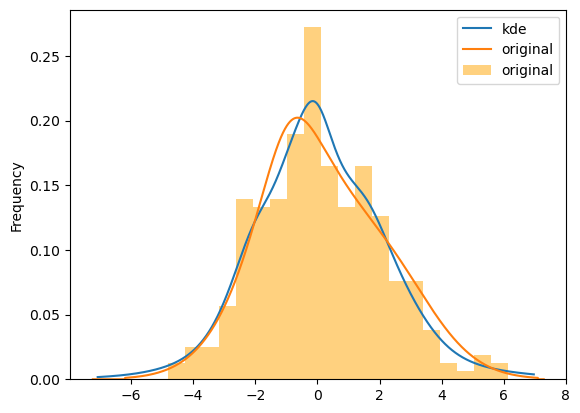

In [77]:
i = 100

kde_databases[0][0]["test"]["df_densities"].iloc[:,i].plot(label="kde")
simulations_database[0]["replications"][0]["densities"].iloc[:,i].plot(label="original")
simulations_database[0]["replications"][0]["samples"].iloc[:,i].plot(kind="hist",density=True,color="orange",label="original", alpha=.5, bins=20)

plt.legend()
plt.show()